<a href="https://colab.research.google.com/github/Lasp10/HandLandMarker/blob/main/handlandmarker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q mediapipe==0.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.9/33.9 MB 60.2 MB/s eta 0:00:00


In [ ]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


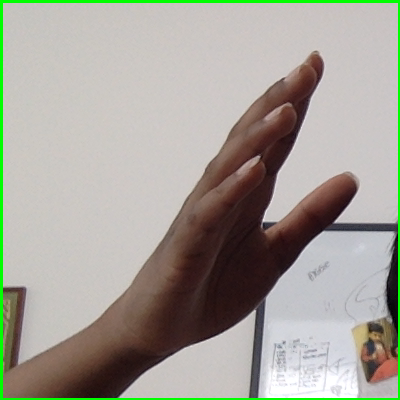

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import pandas as pd

image = cv2.imread('/content/drive/MyDrive/RPSColor/Paper/ Paper 2.png')
cv2_imshow(image)

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.framework.formats import landmark_pb2
import numpy as np


MARGIN = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
HANDEDNESS_TEXT_COLOR = (88, 205, 54) # vibrant green

def draw_landmarks_on_image(rgb_image, detection_result, landmarks_df, image_name):
  hand_landmarks_list = detection_result.hand_landmarks
  handedness_list = detection_result.handedness
  annotated_image = np.copy(rgb_image)

  # Create an empty DataFrame to store the coordinates


  # Loop through the detected hands to visualize and add coordinates to the DataFrame.
  for idx in range(len(hand_landmarks_list)):
    hand_landmarks = hand_landmarks_list[idx]
    handedness = handedness_list[idx]

    # Draw the hand landmarks.
    hand_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    hand_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in hand_landmarks
    ])
    mp.solutions.drawing_utils.draw_landmarks(
      annotated_image,
      hand_landmarks_proto,
      mp.solutions.hands.HAND_CONNECTIONS,
      mp.solutions.drawing_styles.get_default_hand_landmarks_style(),
      mp.solutions.drawing_styles.get_default_hand_connections_style())
    values = []
    # Add coordinates to the DataFrame
    for i, landmark in enumerate(hand_landmarks):
      values.append(landmark.x)
      values.append(landmark.y)
      values.append(landmark.z)

    if image_name == 'Rock/ Rock':
      values.append(0)
    elif image_name == 'Paper/ Paper':
      values.append(1)
    elif image_name == 'Scissors/ Scissors':
      values.append(2)

    landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)

  return annotated_image, landmarks_df

# STEdP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an HandLandmarker object.
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

# STEP 3: Load the input image.
li = ['Paper/ Paper', 'Scissors/ Scissors', 'Rock/ Rock']
landmarks_df = pd.DataFrame()
for x in li:
  for b in range(1, 31):

    image = mp.Image.create_from_file(f"/content/drive/MyDrive/RPSColor/{x} {b}.png")
    print(f"/content/drive/MyDrive/RPSColor/{x} {b}.png")

    # STEP 4: Detect hand landmarks from the input image.
    detection_result = detector.detect(image)

    # Modify the function call to get the annotated image and DataFrame
    annotated_image, landmarks_df = draw_landmarks_on_image(image.numpy_view(), detection_result, landmarks_df, x)

# Print the DataFrame
print(landmarks_df)

# Save the DataFrame to a CSV file
landmarks_df.to_csv('hand_landmarks3.csv', index=False)
print("DataFrame saved to 'hand_landmarks.csv' file.")


/content/drive/MyDrive/RPSColor/Paper/ Paper 1.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 2.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 3.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 4.png


<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)


/content/drive/MyDrive/RPSColor/Paper/ Paper 5.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 6.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 7.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 8.png


<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)


/content/drive/MyDrive/RPSColor/Paper/ Paper 9.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 10.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 11.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 12.png
/content/drive/MyDrive/RPSColor/Paper/ Paper 13.png


...

/content/drive/MyDrive/RPSColor/Rock/ Rock 16.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 17.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 18.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 19.png


<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)
<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)


/content/drive/MyDrive/RPSColor/Rock/ Rock 20.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 21.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 22.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 23.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 24.png


<ipython-input-26-d93ff44e9d2c>:51: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)


/content/drive/MyDrive/RPSColor/Rock/ Rock 25.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 26.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 27.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 28.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 29.png
/content/drive/MyDrive/RPSColor/Rock/ Rock 30.png
          0         1             2         3         4         5         6   \
0   0.378198  0.783141  2.189754e-07  0.568027  0.733516  0.030884  0.666653   
1   0.400604  0.792041  2.093078e-07  0.598691  0.730388  0.046751  0.697711   
2   0.460697  0.788748  2.632659e-07  0.648818  0.729603  0.043890  0.742708   
3   0.451714  0.793269  1.770815e-07  0.639820  0.732224  0.019196  0.740413   
4   0.383135  0.805719  1.737059e-08  0.586515  0.743872  0.041692  0.681996   
5   0.371684  0.819227 -4.940551e-08  0.556829  0.766270  0.011377  0.659450   
6   0.407684  0.810852  2.400814e-07  0.598882  0.746591  0.008421  0.697529   
7   0.424598  0.806996  1.326353e-07  0.608960  0.745815  0.



```
# This is formatted as code
```

# New Section

<ipython-input-7-a8f82b2a2d29>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  landmarks_df = landmarks_df.append(pd.Series(values), ignore_index=True)


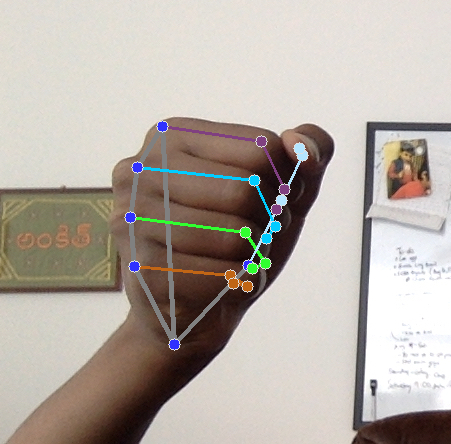

         0         1             2         3         4         5         6   \
0  0.385994  0.776134  1.835366e-07  0.550096  0.597949 -0.068026  0.623188   

         7         8         9   ...        53        54       55        56  \
0  0.451281 -0.136689  0.670345  ... -0.196865  0.510866  0.61959 -0.240803   

        57        58        59       60        61        62  
0  0.54872  0.645193 -0.227264  0.51679  0.639372 -0.213349  

[1 rows x 63 columns]


In [ ]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an HandLandmarker object.
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("/content/rock.jpeg")

# STEP 4: Detect hand landmarks from the input image.
detection_result = detector.detect(image)
landmarks_df = pd.DataFrame()
# STEP 5: Process the classification result. In this case, visualize it.
annotated_image, result = draw_landmarks_on_image(image.numpy_view(), detection_result, landmarks_df)
cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
print(result)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Load the hand landmarks CSV data
landmarks_df = pd.read_csv('hand_landmarks3.csv')

# Define the labels (0: "Paper", 1: "Scissors", 2: "Rock")
labels = ['Paper', 'Scissors', 'Rock']

# Add a new column 'Label' to the DataFrame
# landmarks_df['Label'] = landmarks_df.index // 30  # Assuming there are 30 samples for each gesture

# Split the data into features (hand landmarks) and target (labels)
X = landmarks_df.iloc[:, 0:63]
print(X)


y = landmarks_df.iloc[:, 63:]
print(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a logistic regression model and train it
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict values for the test dataset
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
confusion = confusion_matrix(y_test, y_pred)
print(f'Confusion: {confusion}')

           0         1             2         3         4         5         6  \
0   0.378198  0.783141  2.189754e-07  0.568027  0.733516  0.030884  0.666653   
1   0.400604  0.792041  2.093078e-07  0.598691  0.730388  0.046751  0.697711   
2   0.460697  0.788748  2.632659e-07  0.648818  0.729603  0.043890  0.742708   
3   0.451714  0.793269  1.770815e-07  0.639820  0.732224  0.019196  0.740413   
4   0.383135  0.805719  1.737059e-08  0.586515  0.743872  0.041692  0.681996   
5   0.371684  0.819227 -4.940551e-08  0.556829  0.766270  0.011377  0.659450   
6   0.407684  0.810852  2.400814e-07  0.598882  0.746591  0.008421  0.697529   
7   0.424598  0.806996  1.326353e-07  0.608960  0.745815  0.018663  0.704373   
8   0.438605  0.791766  8.259243e-08  0.627834  0.736287  0.020344  0.724741   
9   0.446511  0.801342  1.494137e-07  0.636713  0.746119  0.023409  0.732148   
10  0.335881  0.723320  8.780725e-07  0.516983  0.625359  0.063308  0.594165   
11  0.291403  0.713511  1.957977e-07  0.

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
np_array = np.array(result).flatten()
print(np_array)

values = model.predict([np_array])
print(values)

[ 3.85994107e-01  7.76133716e-01  1.83536599e-07  5.50095856e-01
  5.97949326e-01 -6.80263042e-02  6.23187780e-01  4.51281428e-01
 -1.36689439e-01  6.70344591e-01  3.51142257e-01 -2.00951755e-01
  6.64549053e-01  3.35439056e-01 -2.49816000e-01  3.60050201e-01
  2.83902943e-01 -1.36526749e-01  5.79769909e-01  3.19106936e-01
 -2.27548808e-01  6.30791366e-01  4.27229583e-01 -2.57685840e-01
  6.13337576e-01  4.72285092e-01 -2.70451963e-01  3.05465013e-01
  3.77733886e-01 -1.49631590e-01  5.65295100e-01  4.06883746e-01
 -2.45842695e-01  6.10055685e-01  5.10284543e-01 -2.50752032e-01
  5.89920104e-01  5.37653089e-01 -2.46042043e-01  2.89206743e-01
  4.90060568e-01 -1.70146942e-01  5.43365479e-01  5.24255753e-01
 -2.56480455e-01  5.88609517e-01  5.92823863e-01 -2.36755371e-01
  5.60154676e-01  6.04013264e-01 -2.11596474e-01  2.97669351e-01
  5.99497080e-01 -1.96865425e-01  5.10866106e-01  6.19590282e-01
 -2.40803495e-01  5.48719943e-01  6.45193040e-01 -2.27263689e-01
  5.16790330e-01  6.39372

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
